In [1]:
!git clone https://github.com/pablo-reyes8/dual-aging-diffusion.git
%cd dual-aging-diffusion

Cloning into 'dual-aging-diffusion'...
remote: Enumerating objects: 345, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 345 (delta 3), reused 5 (delta 3), pack-reused 327 (from 1)
Receiving objects: 100% (345/345), 224.12 MiB | 23.86 MiB/s, done.
Resolving deltas: 100% (102/102), done.
/content/dual-aging-diffusion


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


___


In [3]:
from pathlib import Path
import torch

from data.create_data import (
    build_local_dataloaders,
    build_global_dataloaders,
    build_local_fused_dataloaders,
    build_single_person_sampling_loader,
)


import data.global_path_datasets as global_paths


from src.diffusion_pipeline.load_diffusion_models import (
    build_global_local_bundles,
    build_mixed_lora_dora_training_setup,
)
from src.score_net.load_scorenet import load_score_net_safely
from src.loss.local_loss import LDLALocalAgingLoss
from src.loss.global_loss import GlobalAgingLoss
from src.loss.global_aux_bundle import GlobalLossAuxBundle
from src.training.train_aging_model import train_global_local_face_aging
from src.training.mixed_precision import resolve_device, get_effective_amp_dtype

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda
Dtype: torch.float16
Device: cuda
Dtype: torch.float16


In [4]:
device = resolve_device("auto")
amp_enabled = True
amp_dtype = "bf16"
dtype = get_effective_amp_dtype(amp_dtype=amp_dtype, device=device) or torch.float32

run_name = "notebook_global_local_run"
checkpoint_root = "training_checkpoints/notebook_global_local_run"

In [5]:
global_paths.GLOBAL_IMAGE_DIR = Path("data/global_extracted")
global_paths.GLOBAL_CSV_PATH = Path("data/ffhq_predictions/ffhq_face_attribute_prompts.csv")

global_paths.DRIVE_ZIPS = [
    Path("/content/drive/MyDrive/ffhq_subset_6k_extremes-001.zip"),
    Path("/content/drive/MyDrive/ffhq_subset_6k_extremes-002.zip"),
    Path("/content/drive/MyDrive/ffhq_subset_6k_extremes-003.zip"),
    Path("/content/drive/MyDrive/ffhq_subset_6k_extremes-004.zip"),
]

In [6]:
# Base local crop-level random loader.
# Used by the normal local LDLA loss.
local_objects = build_local_dataloaders(
    batch_size=4,
    num_workers=0,
    pin_memory=False,
)

# Global full-face loader.
# Used by the global branch.
global_objects = build_global_dataloaders(
    batch_size=4,
    num_workers=0,
    pin_memory=False,
)

# Aligned image-level fused-loss loader.
# Used only if use_fused_loss=True.
local_fused_objects = build_local_fused_dataloaders(
    batch_size=1,
    num_workers=0,
    pin_memory=False,
    max_crops_per_image=None,  # None = all available local crops per image
)

# Fixed one-person monitoring loader.
# Same loader is passed as global and local sampling loader.
sampling_objects = build_single_person_sampling_loader(
    image_stem="09501",
    target_age=75,
    local_target_score={
        "default": 85.0,
        "frente": 85.0,
        "surcos_nasogenianos": 85.0,
        "bajo_ojo_ojeras": 85.0,
        "patas_de_gallo": 85.0,
    },
    num_workers=0,
    pin_memory=False)

local_train_loader = local_objects["train_loader"]
global_train_loader = global_objects["train_loader"]
local_fused_train_loader = local_fused_objects["train_loader"]

monitor_loader = sampling_objects["loader"]
sampling_loader_global = monitor_loader
sampling_loader_local = monitor_loader

[OK] JSON annotations already extracted: 56
[OK] Images already extracted: 56
[OK] Indexed unique images: 56
[OK] JSON files found: 56
[OK] Local annotated crop samples: 591
[OK] Unique images: 56
[OK] Train images: 48 | train crops: 503
[OK] Val images:   8 | val crops:   88

========== LOCAL SCORE SAMPLER ==========
Dataset virtual length: 5030
Real samples:           503
Global high share >=75: 9.94%
Anatomical prior:       True

[Region high-score shares]
bajo_ojo_ojeras                  n=  92 >=75=  7 share=  7.61% scarcity_factor=1.082 anatomical_factor=1.250
comisuras_lineas_marioneta       n=  85 >=75= 11 share= 12.94% scarcity_factor=1.000 anatomical_factor=1.250
frente                           n=  44 >=75=  2 share=  4.55% scarcity_factor=1.190 anatomical_factor=1.350
glabela_entrecejo                n=  47 >=75=  6 share= 12.77% scarcity_factor=1.000 anatomical_factor=1.050
labio_superior                   n=  39 >=75=  5 share= 12.82% scarcity_factor=1.000 anatomical_fact

In [7]:
import matplotlib.pyplot as plt

def summarize_batch(batch, name="batch", max_items=3):
    print(f"\n{'='*80}")
    print(f"{name}")
    print(f"{'='*80}")

    if not isinstance(batch, dict):
        print("Batch type:", type(batch))
        print(batch)
        return

    print("\n[KEYS]")
    for k in batch.keys():
        print(" -", k)

    print("\n[VALUES]")
    for k, v in batch.items():
        print(f"\n{k}:")
        print("  type:", type(v))

        if torch.is_tensor(v):
            print("  shape:", tuple(v.shape))
            print("  dtype:", v.dtype)
            print("  device:", v.device)
            if v.numel() > 0 and v.dtype.is_floating_point:
                print("  min:", float(v.min()))
                print("  max:", float(v.max()))
                print("  mean:", float(v.mean()))
            elif v.numel() > 0:
                print("  first values:", v.flatten()[:10].tolist())

        elif isinstance(v, (list, tuple)):
            print("  len:", len(v))
            for i, item in enumerate(v[:max_items]):
                print(f"  [{i}] {type(item)}:", item)

        elif isinstance(v, dict):
            print("  dict keys:", list(v.keys()))
            for kk, vv in list(v.items())[:max_items]:
                print(f"    {kk}: {type(vv)} -> {vv}")

        else:
            print("  value:", v)


def tensor_to_image(x):
    """
    Converts a CHW tensor to HWC image for matplotlib.
    Assumes either [-1, 1] or [0, 1].
    """
    if x.ndim != 3:
        raise ValueError(f"Expected CHW tensor, got shape {tuple(x.shape)}")

    x = x.detach().cpu().float()

    # If diffusion-normalized [-1, 1], map to [0, 1]
    if float(x.min()) < 0:
        x = (x + 1.0) / 2.0

    x = x.clamp(0, 1)
    x = x.permute(1, 2, 0).numpy()
    return x


def show_batch_images(batch, image_keys=None, n=4, title_prefix=""):
    """
    Tries to display image tensors from a batch.
    """
    if image_keys is None:
        image_keys = [
            "pixel_values",
            "image",
            "images",
            "global_image",
            "local_image",
            "crop",
            "crops",
        ]

    found = False

    for key in image_keys:
        if key not in batch:
            continue

        value = batch[key]

        if not torch.is_tensor(value):
            continue

        if value.ndim == 4:
            # B, C, H, W
            found = True
            b = min(n, value.shape[0])

            for i in range(b):
                plt.figure(figsize=(4, 4))
                plt.imshow(tensor_to_image(value[i]))
                plt.axis("off")
                plt.title(f"{title_prefix}{key}[{i}]")
                plt.show()

        elif value.ndim == 5:
            # B, N, C, H, W, useful for fused local crops
            found = True
            b = min(value.shape[0], 1)
            num_crops = min(n, value.shape[1])

            for bi in range(b):
                for ci in range(num_crops):
                    plt.figure(figsize=(4, 4))
                    plt.imshow(tensor_to_image(value[bi, ci]))
                    plt.axis("off")
                    plt.title(f"{title_prefix}{key}[batch={bi}, crop={ci}]")
                    plt.show()

    if not found:
        print("No obvious image tensor key found.")

def print_prompt_like_fields(batch, max_items=5):
    print("\n[PROMPT / TEXT / METADATA FIELDS]")

    keywords = [
        "prompt",
        "text",
        "caption",
        "region",
        "age",
        "score",
        "filename",
        "image",
        "stem",
        "path",
        "bbox",
        "box",
    ]

    for k, v in batch.items():
        k_lower = k.lower()
        if any(word in k_lower for word in keywords):
            print(f"\n{k}:")
            if torch.is_tensor(v):
                print("  tensor shape:", tuple(v.shape), "dtype:", v.dtype)
                print("  values:", v.flatten()[:max_items].detach().cpu().tolist())
            elif isinstance(v, (list, tuple)):
                for i, item in enumerate(v[:max_items]):
                    print(f"  [{i}] {item}")
            else:
                print(" ", v)



LOCAL TRAIN BATCH

[KEYS]
 - pixel_values
 - score
 - score_raw
 - score_original
 - prompt
 - zone_prompt
 - region_key
 - region_name
 - region_alias
 - image_id
 - image_stem
 - box_index
 - demographic_context
 - bbox_original
 - bbox_crop
 - json_path

[VALUES]

pixel_values:
  type: <class 'torch.Tensor'>
  shape: (4, 3, 256, 256)
  dtype: torch.float32
  device: cpu
  min: -1.0
  max: 0.9529411792755127
  mean: 0.23329788446426392

score:
  type: <class 'torch.Tensor'>
  shape: (4,)
  dtype: torch.float32
  device: cpu
  min: 0.0
  max: 0.8500000238418579
  mean: 0.5550000071525574

score_raw:
  type: <class 'torch.Tensor'>
  shape: (4,)
  dtype: torch.float32
  device: cpu
  min: 0.0
  max: 85.0
  mean: 55.5

score_original:
  type: <class 'torch.Tensor'>
  shape: (4,)
  dtype: torch.float32
  device: cpu
  min: 0.0
  max: 89.0
  mean: 54.75

prompt:
  type: <class 'list'>
  len: 4
  [0] <class 'str'>: a tightly cropped, centered close-up of the nasolabial fold region, showing

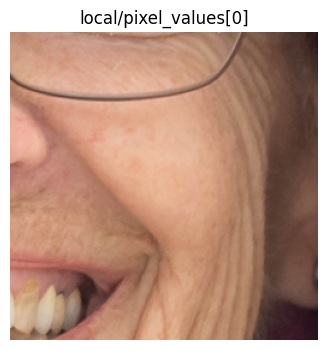

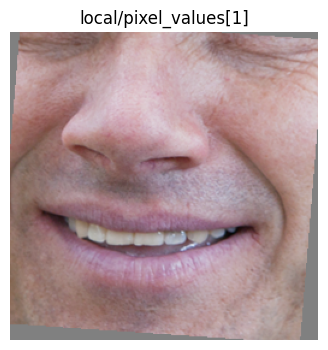

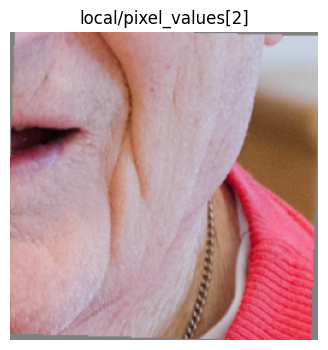

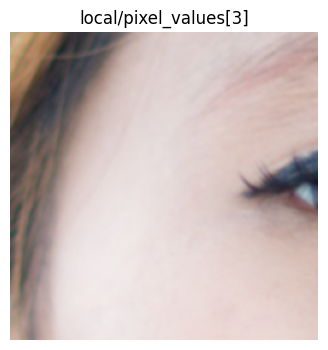

In [8]:
local_batch = next(iter(local_train_loader))

summarize_batch(local_batch, name="LOCAL TRAIN BATCH")
print_prompt_like_fields(local_batch, max_items=8)
show_batch_images(local_batch, n=4, title_prefix="local/")


GLOBAL TRAIN BATCH

[KEYS]
 - pixel_values
 - age
 - age_norm
 - prompt

[VALUES]

pixel_values:
  type: <class 'torch.Tensor'>
  shape: (4, 3, 512, 512)
  dtype: torch.float32
  device: cpu
  min: -1.0
  max: 1.0
  mean: -0.2749602794647217

age:
  type: <class 'torch.Tensor'>
  shape: (4,)
  dtype: torch.float32
  device: cpu
  min: 44.79999923706055
  max: 54.900001525878906
  mean: 50.75

age_norm:
  type: <class 'torch.Tensor'>
  shape: (4,)
  dtype: torch.float32
  device: cpu
  min: 0.4480000138282776
  max: 0.5490000247955322
  mean: 0.5074999928474426

prompt:
  type: <class 'list'>
  len: 4
  [0] <class 'str'>: a portrait photo of a 55-year-old person, dark skin tone, gray hair, wearing glasses
  [1] <class 'str'>: a portrait photo of a 45-year-old person, medium skin tone, brown hair
  [2] <class 'str'>: a portrait photo of a 55-year-old person, medium skin tone, brown hair

[PROMPT / TEXT / METADATA FIELDS]

age:
  tensor shape: (4,) dtype: torch.float32
  values: [54.9000

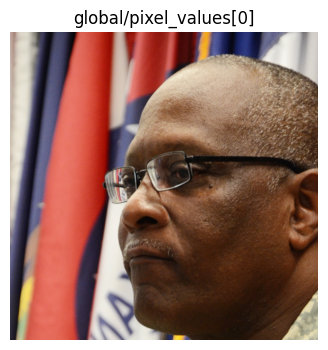

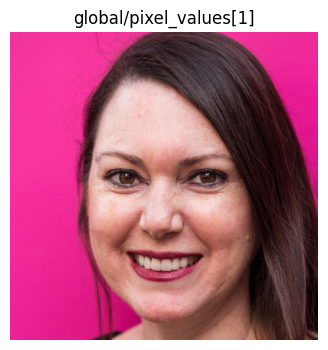

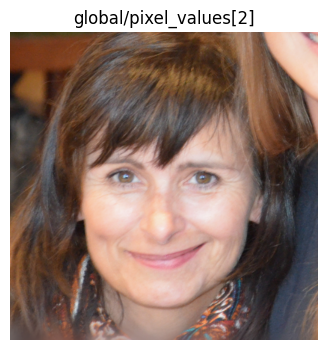

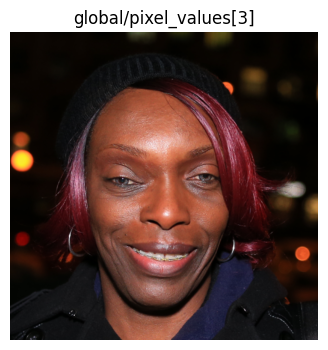

In [9]:
global_batch = next(iter(global_train_loader))

summarize_batch(global_batch, name="GLOBAL TRAIN BATCH")
print_prompt_like_fields(global_batch, max_items=8)
show_batch_images(global_batch, n=4, title_prefix="global/")


LOCAL FUSED TRAIN BATCH

[KEYS]
 - full_pixel_values
 - pixel_values
 - masks
 - boxes
 - target_scores
 - valid_mask
 - prompt
 - zone_prompt
 - region_key
 - image_id
 - image_stem
 - image_path
 - global_prompt

[VALUES]

full_pixel_values:
  type: <class 'torch.Tensor'>
  shape: (1, 3, 512, 512)
  dtype: torch.float32
  device: cpu
  min: -1.0
  max: 1.0
  mean: -0.24504482746124268

pixel_values:
  type: <class 'torch.Tensor'>
  shape: (1, 12, 3, 256, 256)
  dtype: torch.float32
  device: cpu
  min: -1.0
  max: 1.0
  mean: -0.12919604778289795

masks:
  type: <class 'torch.Tensor'>
  shape: (1, 12, 1, 256, 256)
  dtype: torch.float32
  device: cpu
  min: 0.0
  max: 1.0
  mean: 0.8212890625

boxes:
  type: <class 'torch.Tensor'>
  shape: (1, 12, 4)
  dtype: torch.int64
  device: cpu
  first values: [121, 19, 374, 272, 214, 172, 306, 265, 80, 202]

target_scores:
  type: <class 'torch.Tensor'>
  shape: (1, 12)
  dtype: torch.float32
  device: cpu
  min: 0.0
  max: 0.5
  mean: 0.204

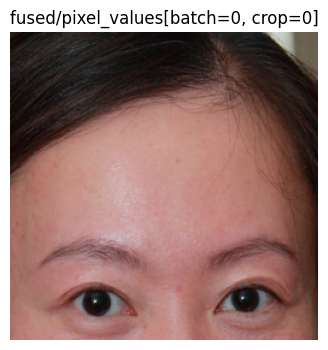

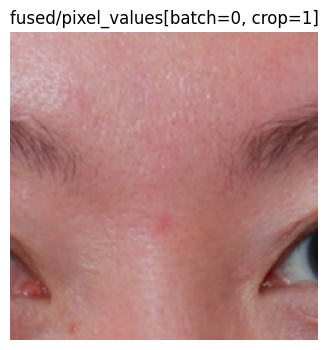

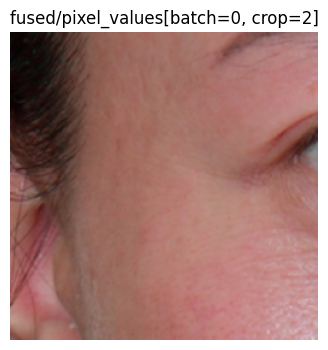

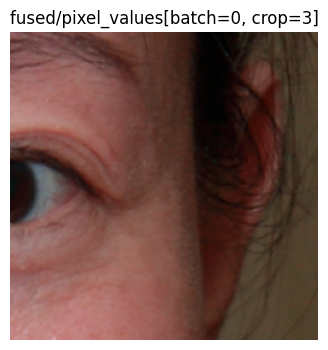

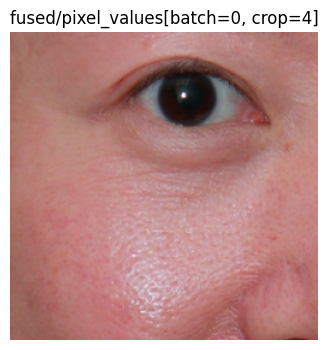

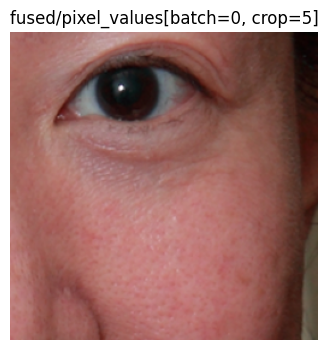

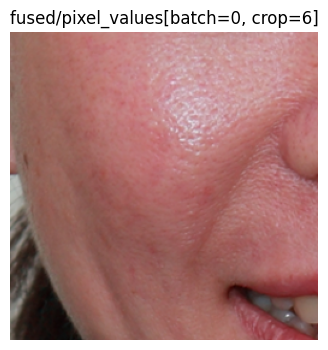

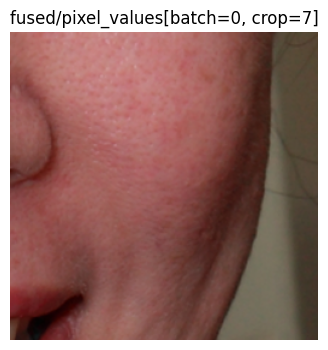

In [10]:
fused_batch = next(iter(local_fused_train_loader))

summarize_batch(fused_batch, name="LOCAL FUSED TRAIN BATCH")
print_prompt_like_fields(fused_batch, max_items=8)
show_batch_images(fused_batch, n=8, title_prefix="fused/")

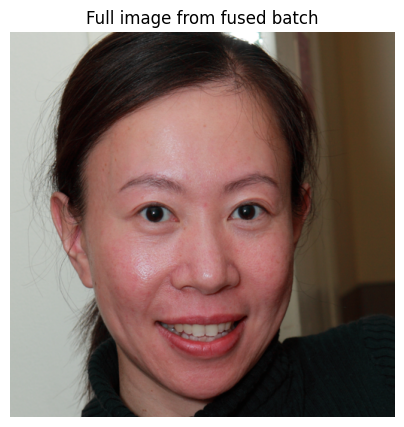

In [12]:
full = fused_batch["full_pixel_values"]

plt.figure(figsize=(5, 5))
plt.imshow(tensor_to_image(full[0]))
plt.axis("off")
plt.title("Full image from fused batch")
plt.show()

In [11]:
monitor_batch = next(iter(monitor_loader))

summarize_batch(monitor_batch, name="MONITOR / SINGLE PERSON BATCH")
print_prompt_like_fields(monitor_batch, max_items=20)
show_batch_images(monitor_batch, n=10, title_prefix="monitor/")


MONITOR / SINGLE PERSON BATCH

[KEYS]
 - x_orig
 - image
 - global_prompt
 - image_id
 - id
 - zones

[VALUES]

x_orig:
  type: <class 'torch.Tensor'>
  shape: (3, 512, 512)
  dtype: torch.float32
  device: cpu
  min: 0.01568627543747425
  max: 1.0
  mean: 0.545314371585846

image:
  type: <class 'torch.Tensor'>
  shape: (3, 512, 512)
  dtype: torch.float32
  device: cpu
  min: 0.01568627543747425
  max: 1.0
  mean: 0.545314371585846

global_prompt:
  type: <class 'str'>
  value: a portrait photo of a 75-year-old person, medium skin tone, black hair

image_id:
  type: <class 'str'>
  value: 09501.png

id:
  type: <class 'str'>
  value: 09501

zones:
  type: <class 'list'>
  len: 8
  [0] <class 'dict'>: {'zone_name': 'frente', 'crop': tensor([[[0.1725, 0.2157, 0.2353,  ..., 0.9255, 0.9333, 0.9333],
         [0.2353, 0.2549, 0.2471,  ..., 0.9216, 0.9294, 0.9294],
         [0.2627, 0.2510, 0.2667,  ..., 0.9098, 0.9176, 0.9294],
         ...,
         [0.7922, 0.7843, 0.7765,  ..., 0.7608

MONITOR BATCH
image_id: 09501.png
id: 09501
global_prompt: a portrait photo of a 75-year-old person, medium skin tone, black hair

image shape: (3, 512, 512)
x_orig shape: (3, 512, 512)
num zones: 8


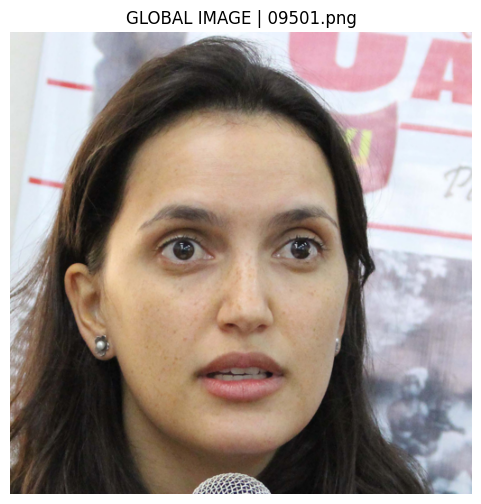

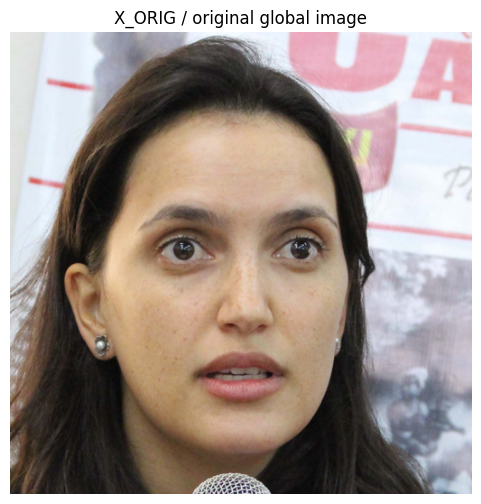


--------------------------------------------------------------------------------
ZONE 0: frente
bbox: (148, 55, 358, 266)
target_score: 0.85
prompt: a tightly cropped, centered close-up of the forehead region, showing facial skin texture and local aging details, with an aging score of 85%, for a white person
crop shape: (3, 256, 256)
crop min/max/mean: 0.027450980618596077 1.0 0.5085021257400513


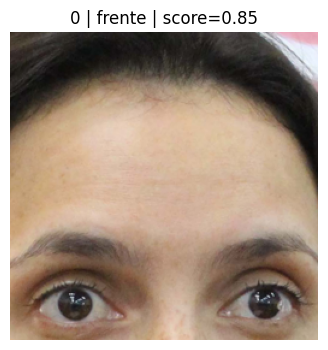

mask shape: (1, 256, 256)
mask min/max/mean: 0.0 1.0 0.8212890625


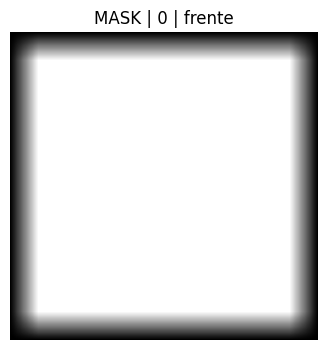


--------------------------------------------------------------------------------
ZONE 1: glabela_entrecejo
bbox: (224, 174, 302, 251)
target_score: 0.85
prompt: a tightly cropped, centered close-up of the glabellar region between the eyebrows, showing facial skin texture and local aging details, with an aging score of 85%, for a white person
crop shape: (3, 256, 256)
crop min/max/mean: 0.1411764770746231 0.886274516582489 0.581676721572876


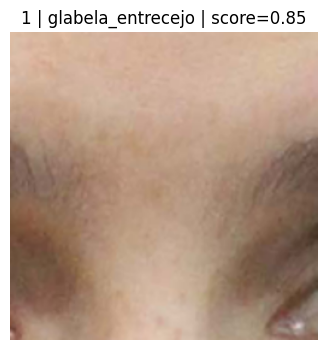

mask shape: (1, 256, 256)
mask min/max/mean: 0.0 1.0 0.8212890625


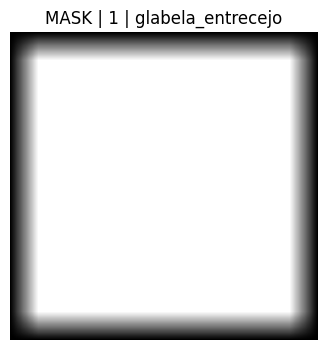


--------------------------------------------------------------------------------
ZONE 2: patas_de_gallo
bbox: (96, 198, 187, 290)
target_score: 0.85
prompt: a tightly cropped, centered close-up of the crow's feet region at the outer eye corner, showing facial skin texture and local aging details, with an aging score of 85%, for a white person
crop shape: (3, 256, 256)
crop min/max/mean: 0.0235294122248888 0.9843137264251709 0.5664242506027222


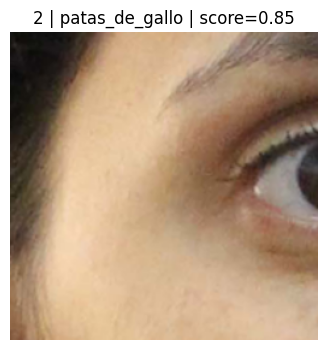

mask shape: (1, 256, 256)
mask min/max/mean: 0.0 1.0 0.8212890625


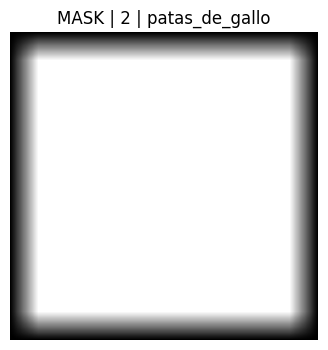


--------------------------------------------------------------------------------
ZONE 3: bajo_ojo_ojeras
bbox: (136, 224, 246, 334)
target_score: 0.85
prompt: a tightly cropped, centered close-up of the under-eye region, showing facial skin texture and local aging details, with an aging score of 85%, for a white person
crop shape: (3, 256, 256)
crop min/max/mean: 0.04313725605607033 0.9686274528503418 0.5826749801635742


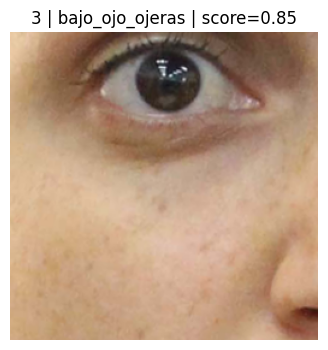

mask shape: (1, 256, 256)
mask min/max/mean: 0.0 1.0 0.8212890625


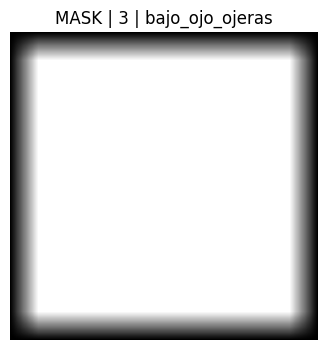


--------------------------------------------------------------------------------
ZONE 4: surcos_nasogenianos
bbox: (114, 267, 246, 400)
target_score: 0.85
prompt: a tightly cropped, centered close-up of the nasolabial fold region, showing facial skin texture and local aging details, with an aging score of 85%, for a white person
crop shape: (3, 256, 256)
crop min/max/mean: 0.003921568859368563 0.95686274766922 0.6041082739830017


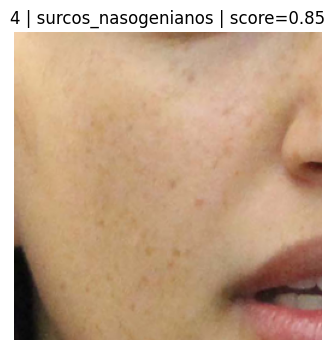

mask shape: (1, 256, 256)
mask min/max/mean: 0.0 1.0 0.8212890625


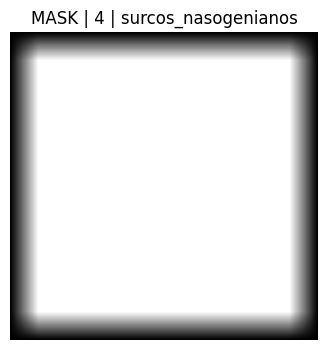


--------------------------------------------------------------------------------
ZONE 5: labio_superior
bbox: (186, 266, 333, 414)
target_score: 0.85
prompt: a tightly cropped, centered close-up of the upper lip region, showing facial skin texture and local aging details, with an aging score of 85%, for a white person
crop shape: (3, 256, 256)
crop min/max/mean: 0.027450980618596077 0.9450980424880981 0.586848795413971


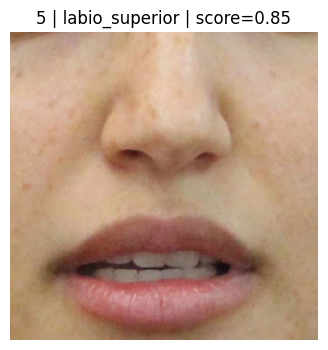

mask shape: (1, 256, 256)
mask min/max/mean: 0.0 1.0 0.8212890625


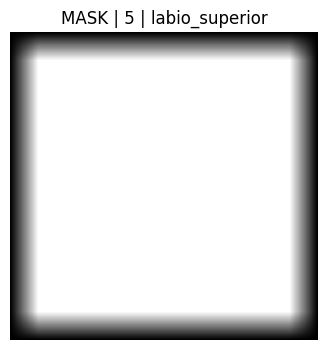


--------------------------------------------------------------------------------
ZONE 6: comisuras_lineas_marioneta
bbox: (104, 336, 224, 456)
target_score: 0.85
prompt: a tightly cropped, centered close-up of the mouth corner and marionette line region, showing facial skin texture and local aging details, with an aging score of 85%, for a white person
crop shape: (3, 256, 256)
crop min/max/mean: 0.007843137718737125 0.9450980424880981 0.448940247297287


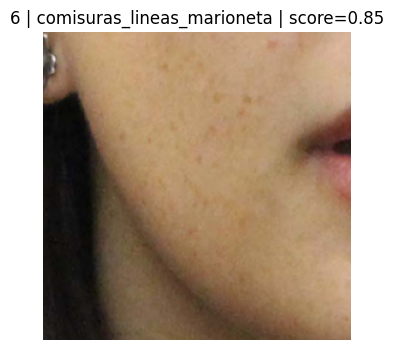

mask shape: (1, 256, 256)
mask min/max/mean: 0.0 1.0 0.8212890625


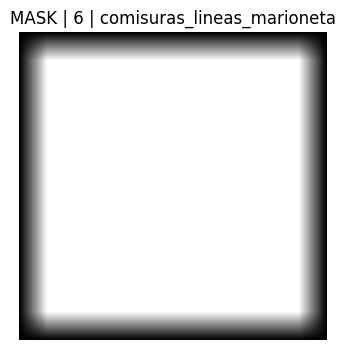


--------------------------------------------------------------------------------
ZONE 7: puente_nasal
bbox: (230, 240, 296, 306)
target_score: 0.85
prompt: a tightly cropped, centered close-up of the nasal bridge and inter-ocular region, showing facial skin texture and local aging details, with an aging score of 85%, for a white person
crop shape: (3, 256, 256)
crop min/max/mean: 0.16862745583057404 0.9450980424880981 0.675754964351654


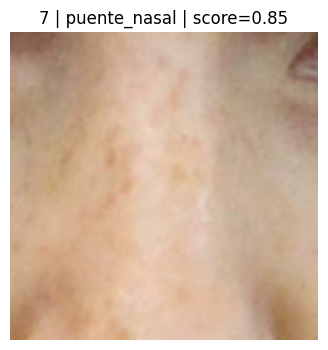

mask shape: (1, 256, 256)
mask min/max/mean: 0.0 1.0 0.8212890625


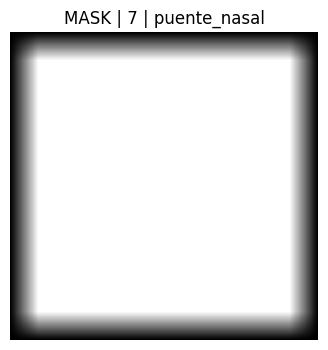

In [16]:
import matplotlib.pyplot as plt
import torch


# ------------------------------------------------------------
# Get one monitor batch
# ------------------------------------------------------------
monitor_batch = next(iter(monitor_loader))


# ------------------------------------------------------------
# Helper: CHW tensor -> HWC image
# Supports [0, 1] and [-1, 1]
# ------------------------------------------------------------
def _to_img(x):
    x = x.detach().cpu().float()

    if x.ndim != 3:
        raise ValueError(f"Expected CHW tensor, got shape {tuple(x.shape)}")

    if float(x.min()) < 0:
        x = (x + 1.0) / 2.0

    x = x.clamp(0, 1)
    return x.permute(1, 2, 0).numpy()


# ------------------------------------------------------------
# Print global metadata
# ------------------------------------------------------------
print("=" * 80)
print("MONITOR BATCH")
print("=" * 80)

print("image_id:", monitor_batch.get("image_id"))
print("id:", monitor_batch.get("id"))
print("global_prompt:", monitor_batch.get("global_prompt"))

print("\nimage shape:", tuple(monitor_batch["image"].shape))
print("x_orig shape:", tuple(monitor_batch["x_orig"].shape))
print("num zones:", len(monitor_batch["zones"]))


# ------------------------------------------------------------
# Show global image
# ------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.imshow(_to_img(monitor_batch["image"]))
plt.axis("off")
plt.title(f"GLOBAL IMAGE | {monitor_batch.get('image_id')}")
plt.show()


# ------------------------------------------------------------
# Optional: show x_orig too, to confirm it matches image
# ------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.imshow(_to_img(monitor_batch["x_orig"]))
plt.axis("off")
plt.title("X_ORIG / original global image")
plt.show()


# ------------------------------------------------------------
# Show local crops
# ------------------------------------------------------------
for i, zone in enumerate(monitor_batch["zones"]):
    zone_name = zone.get("zone_name")
    crop = zone.get("crop")
    mask = zone.get("mask")
    bbox = zone.get("bbox")
    prompt = zone.get("prompt")
    target_score = zone.get("target_score")

    print("\n" + "-" * 80)
    print(f"ZONE {i}: {zone_name}")
    print("bbox:", bbox)
    print("target_score:", target_score)
    print("prompt:", prompt)

    if torch.is_tensor(crop):
        print("crop shape:", tuple(crop.shape))
        print("crop min/max/mean:", float(crop.min()), float(crop.max()), float(crop.mean()))

        plt.figure(figsize=(4, 4))
        plt.imshow(_to_img(crop))
        plt.axis("off")
        plt.title(f"{i} | {zone_name} | score={target_score}")
        plt.show()

    if torch.is_tensor(mask):
        print("mask shape:", tuple(mask.shape))
        print("mask min/max/mean:", float(mask.min()), float(mask.max()), float(mask.mean()))

        plt.figure(figsize=(4, 4))
        plt.imshow(mask.detach().cpu().float().squeeze().numpy(), cmap="gray")
        plt.axis("off")
        plt.title(f"MASK | {i} | {zone_name}")
        plt.show()

---

In [17]:
global_bundle, local_bundle = build_global_local_bundles(
    global_model_id="SG161222/Realistic_Vision_V6.0_B1_noVAE",
    global_vae_id="stabilityai/sd-vae-ft-mse",
    local_model_id="SG161222/Realistic_Vision_V6.0_B1_noVAE",
    local_vae_id=None,
    device=device,
    dtype=dtype,
    print_memory=True,
)


BUILDING GLOBAL + LOCAL BUNDLES
Global model id: SG161222/Realistic_Vision_V6.0_B1_noVAE
Global VAE id: stabilityai/sd-vae-ft-mse
Global uses external VAE: True
--------------------------------------------------------------------------------
Local model id: SG161222/Realistic_Vision_V6.0_B1_noVAE
Local VAE id: stabilityai/sd-vae-ft-mse
Local uses external VAE: True

[Loading diffusion components]
Model id: SG161222/Realistic_Vision_V6.0_B1_noVAE
Use external VAE: True


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/737 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]


[Loaded Components]
Tokenizer: <class 'transformers.models.clip.tokenization_clip.CLIPTokenizer'>
Text encoder: <class 'transformers.models.clip.modeling_clip.CLIPTextModel'>
UNet: <class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>
Scheduler train: <class 'diffusers.schedulers.scheduling_ddpm.DDPMScheduler'>
Scheduler infer: <class 'diffusers.schedulers.scheduling_ddim.DDIMScheduler'>
VAE: <class 'diffusers.models.autoencoders.autoencoder_kl.AutoencoderKL'>

[Config Checks]
Bundle model id: SG161222/Realistic_Vision_V6.0_B1_noVAE
Bundle VAE id: stabilityai/sd-vae-ft-mse
VAE scaling factor: 0.18215
UNet in_channels: 4
UNet cross_attention_dim: 768
Scheduler num_train_timesteps: 1000
[After loading GLOBAL bundle] allocated=2.01 GB | reserved=2.06 GB | max=2.01 GB

[Loading diffusion components]
Model id: SG161222/Realistic_Vision_V6.0_B1_noVAE
Use external VAE: True


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: SG161222/Realistic_Vision_V6.0_B1_noVAE
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch SG161222/Realistic_Vision_V6.0_B1_noVAE: SG161222/Realistic_Vision_V6.0_B1_noVAE does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading external VAE: stabilityai/sd-vae-ft-mse

[Loaded Components]
Tokenizer: <class 'transformers.models.clip.tokenization_clip.CLIPTokenizer'>
Text encoder: <class 'transformers.models.clip.modeling_clip.CLIPTextModel'>
UNet: <class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>
Scheduler train: <class 'diffusers.schedulers.scheduling_ddpm.DDPMScheduler'>
Scheduler infer: <class 'diffusers.schedulers.scheduling_ddim.DDIMScheduler'>
VAE: <class 'diffusers.models.autoencoders.autoencoder_kl.AutoencoderKL'>

[Config Checks]
Bundle model id: SG161222/Realistic_Vision_V6.0_B1_noVAE
Bundle VAE id: stabilityai/sd-vae-ft-mse
VAE scaling factor: 0.18215
UNet in_channels: 4
UNet cross_attention_dim: 768
Scheduler num_train_timesteps: 1000
[After loading LOCAL bundle] allocated=4.03 GB | reserved=4.08 GB | max=4.03 GB

[OK] Built global_bundle and local_bundle
Global bundle name: Global_Realistic_Vision_V6.0_B1_noVAE
Local bundle name: Local_Realistic_Vision_V6.0_B1_noVAE


In [18]:
# Targets Can be: ["to_q", "to_k", "to_v", "to_out.0"] to be more agresive
# Or even more Agresive: target_modules = ["to_q", "to_k", "to_v", "to_out.0","ff.net.0.proj","ff.net.2",]

mixed_global_bundle, mixed_local_bundle = build_mixed_lora_dora_training_setup(
    global_bundle=global_bundle,
    local_bundle=local_bundle,
    global_adapter_config={
        "adapter_type": "lora",
        "rank": 8,
        "alpha": 8,
        "dropout": 0.0,
        "target_suffixes": ["to_q", "to_k", "to_v", "to_out.0"],
    },
    local_adapter_config={
        "adapter_type": "dora",
        "rank": 16,
        "alpha": 16,
        "dropout": 0.05,
        "target_suffixes": ["to_q", "to_k", "to_v", "to_out.0"],
    },
    optimizer_config={
        "lr": 1e-4,
        "betas": (0.9, 0.999),
        "weight_decay": 1e-2,
    },
    freeze_before_injection=True,
    print_memory=True,
    print_reports=True,
    verbose=True,
)

[Before adapter injection] allocated=4.03 GB | reserved=4.08 GB | max=4.03 GB

[Applying LORA to existing UNet]
Bundle: Mixed_Global_LORA_Realistic_Vision_V6.0_B1_noVAE
Model id: SG161222/Realistic_Vision_V6.0_B1_noVAE
Rank: 8
Alpha: 8
Dropout: 0.0
Targets: ['to_q', 'to_k', 'to_v', 'to_out.0']

Found Linear modules to LoRA-wrap: 128
  down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q                                 | 320->320
  down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k                                 | 320->320
  down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_v                                 | 320->320
  down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0                             | 320->320
  down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_q                                 | 320->320
  down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_k                                 | 768->320
  down_blocks.0.attentions.0.transformer_

In [21]:
score_net = load_score_net_safely(
    checkpoint_path="models/score net/score_net_last_test1.pt",
    device=str(device),
    dtype=torch.float32,
    base_channels=32,
    dropout=0.15,
    strict=True,
    freeze=True,
)


========== SAFE SCORENET LOAD ==========
checkpoint_path: models/score net/score_net_last_test1.pt
target device: cuda
dtype: torch.float32
[Before loading ScoreNet] allocated=4.04 GB | reserved=4.09 GB | max=4.04 GB

[OK] ScoreNet loaded safely
freeze: True
eval_mode: True

[ScoreNet params]
total params:     439,561
trainable params: 0
frozen params:    439,561
[After loading ScoreNet] allocated=4.04 GB | reserved=4.09 GB | max=4.04 GB


In [22]:
local_loss = LDLALocalAgingLoss(
    local_bundle=mixed_local_bundle,
    score_net=score_net,
    lambda_full=1.0,
    lambda_zone=0.25,
    lambda_score=0.05,
    lambda_cycle=0.0,
    device=str(device),
)

In [ ]:
!pip install --no-deps facenet-pytorch

In [25]:
global_aux_bundle = GlobalLossAuxBundle(
    device=str(device),
    dtype=torch.float32,
    use_age=True,
    age_model_id="nateraw/vit-age-classifier",
    age_image_size=224,
    use_identity=True,
    identity_pretrained="vggface2",
    identity_image_size=160,
    use_lpips=False,
)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[OK] Loaded HFAgeEstimator
model_id: nateraw/vit-age-classifier
num age classes: 9
age values: [1.0, 6.0, 14.5, 24.5, 34.5, 44.5, 54.5, 64.5, 70.0]


  0%|          | 0.00/107M [00:00<?, ?B/s]

[OK] Loaded FaceNetIdentityEncoder
pretrained: vggface2

========== GLOBAL LOSS AUX BUNDLE ==========
use_age: True
use_identity: True
use_lpips: False
device: cuda
dtype: torch.float32


In [26]:
global_loss = GlobalAgingLoss(
    global_bundle=mixed_global_bundle,
    global_loss_bundle=global_aux_bundle,
    lambda_diff=1.0,
    lambda_id=0.5,
    lambda_age=0.25,
    lambda_delta_age=0.25,
    lambda_perc=0.0,
    device=str(device),
)


========== GLOBAL AGING LOSS ==========
lambda_diff: 1.0
lambda_id: 0.5
lambda_age: 0.25
lambda_delta_age: 0.25
lambda_perc: 0.0
age_loss_scale: 100.0
gamma_timestep: 1.0
timestep range: 0 999
semantic timestep range: 20 300
default_semantic_components: ('age', 'delta_age', 'id')
device: cuda
unet_dtype: torch.bfloat16
